# WV3-Pretrained HAT Transfer to the 6-Band Dataset

This notebook transfers the HAT-PAN model pretrained on PanCollection WorldView-3:

```text
WV3: 8 MS + 1 PAN → 8 MS
```

to the project architecture:

```text
Project: 6 MS + 1 PAN → 6 MS
```

The Transformer/Attention body is transferred directly. Layers whose channel counts differ are adapted explicitly, then fine-tuned on the project Train/Validation/Test split.


## 1) تفعيل GPU

في Colab:

```text
Runtime → Change runtime type → T4 GPU
```


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("شغّل الـNotebook باستخدام GPU.")


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2) تثبيت HAT والمكتبات

In [2]:
from pathlib import Path
import shutil
import subprocess
import sys

%cd /content

HAT_REPO = Path("/content/HAT")

if HAT_REPO.exists():
    shutil.rmtree(HAT_REPO)

subprocess.run(
    [
        "git", "clone", "--depth", "1",
        "https://github.com/XPixelGroup/HAT.git",
        str(HAT_REPO),
    ],
    check=True,
)

!pip install -q einops timm matplotlib tqdm scikit-image

print("HAT repository:", HAT_REPO)


/content
HAT repository: /content/HAT


## 3) WV3 pretrained checkpoint

In [3]:
# The WV3 checkpoint is stored on Google Drive and will be defined after Drive is mounted.
print("WV3 checkpoint will be loaded from Google Drive.")


WV3 checkpoint will be loaded from Google Drive.


## 4) Google Drive and project paths

In [4]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

DATA_DIR = PROJECT_DIR / "Wald_Data_GSD" / "Patches"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

BASELINE_DIR = PROJECT_DIR / "Fusion_Baseline_Results"
BASELINE_STATS_PATH = BASELINE_DIR / "train_normalization_stats.json"
BASELINE_METRICS_PATH = BASELINE_DIR / "test_metrics.json"

OLD_HAT_METRICS_PATH = (
    PROJECT_DIR / "HAT_PAN_Fusion_Results" / "hat_test_metrics.json"
)

WV3_CHECKPOINT_PATH = (
    PROJECT_DIR
    / "WV3_HAT_Pretraining"
    / "best_wv3_hat_pan_pretrained.pth"
)

OUTPUT_DIR = PROJECT_DIR / "WV3_Transfer_HAT_Results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STAGE_A_MODEL = OUTPUT_DIR / "best_transfer_stage_a.pth"
BEST_MODEL_PATH = OUTPUT_DIR / "best_wv3_transfer_hat_6band.pth"
LAST_MODEL_PATH = OUTPUT_DIR / "last_wv3_transfer_hat_6band.pth"
HISTORY_PATH = OUTPUT_DIR / "transfer_training_history.json"
TEST_METRICS_PATH = OUTPUT_DIR / "transfer_test_metrics.json"

for path in [
    TRAIN_DIR,
    VAL_DIR,
    TEST_DIR,
    BASELINE_STATS_PATH,
    WV3_CHECKPOINT_PATH,
]:
    print(path, "→", path.exists())
    if not path.exists():
        raise FileNotFoundError(path)

print("Output:", OUTPUT_DIR)


Mounted at /content/drive
/content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/train → True
/content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/val → True
/content/drive/MyDrive/Super_Resolution_28-07-2026/Wald_Data_GSD/Patches/test → True
/content/drive/MyDrive/Super_Resolution_28-07-2026/Fusion_Baseline_Results/train_normalization_stats.json → True
/content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_HAT_Pretraining/best_wv3_hat_pan_pretrained.pth → True
Output: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_Transfer_HAT_Results


## 5) إعدادات التدريب

In [5]:
import os
import random
import json
import numpy as np

SEED = 42

BATCH_SIZE = 1
ACCUMULATION_STEPS = 4
NUM_WORKERS = 0

# ابدأ بهذه القيم. يمكن زيادتها لاحقًا.
STAGE_A_EPOCHS = 5
STAGE_B_EPOCHS = 10

STAGE_A_LR = 5e-5
STAGE_B_LR = 1e-5

WEIGHT_DECAY = 1e-6

# HAT attention is trained in full float32 for numerical stability.
USE_AMP = False

SCALE = 4
MS_BANDS = 6

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda")

print("Device:", device)
print("Effective batch size:", BATCH_SIZE * ACCUMULATION_STEPS)


Device: cuda
Effective batch size: 4


## 6) تحميل Normalization المستخدمة في الـCNN

In [6]:
with open(BASELINE_STATS_PATH, "r", encoding="utf-8") as file:
    stats = json.load(file)

MS_LOW = np.array(
    [item["p01"] for item in stats["ms"]],
    dtype=np.float32,
)[:, None, None]

MS_HIGH = np.array(
    [item["p99"] for item in stats["ms"]],
    dtype=np.float32,
)[:, None, None]

PAN_LOW = np.float32(stats["pan"]["p01"])
PAN_HIGH = np.float32(stats["pan"]["p99"])


def normalize_ms(array):
    array = array.astype(np.float32)

    return np.clip(
        (array - MS_LOW) / (MS_HIGH - MS_LOW),
        0,
        1,
    )


def normalize_pan(array):
    array = array.astype(np.float32)

    return np.clip(
        (array - PAN_LOW) / (PAN_HIGH - PAN_LOW),
        0,
        1,
    )


print("Normalization loaded.")


Normalization loaded.


## 7) Dataset وDataLoader

In [7]:
from torch.utils.data import Dataset, DataLoader


class WaldPatchDataset(Dataset):
    def __init__(self, folder, augment=False):
        self.files = sorted(Path(folder).glob("*.npz"))
        self.augment = augment

        if not self.files:
            raise RuntimeError(f"No files in {folder}")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        file_path = self.files[index]

        with np.load(file_path) as sample:
            lr_ms = sample["lr_ms"].copy()
            pan = sample["pan"].copy()
            target = sample["target_ms"].copy()

        lr_ms = torch.from_numpy(normalize_ms(lr_ms)).float()
        pan = torch.from_numpy(normalize_pan(pan)).float()
        target = torch.from_numpy(normalize_ms(target)).float()

        if self.augment:
            if random.random() < 0.5:
                lr_ms = torch.flip(lr_ms, dims=[2])
                pan = torch.flip(pan, dims=[2])
                target = torch.flip(target, dims=[2])

            if random.random() < 0.5:
                lr_ms = torch.flip(lr_ms, dims=[1])
                pan = torch.flip(pan, dims=[1])
                target = torch.flip(target, dims=[1])

            rotations = random.randint(0, 3)

            if rotations:
                lr_ms = torch.rot90(lr_ms, rotations, dims=[1, 2])
                pan = torch.rot90(pan, rotations, dims=[1, 2])
                target = torch.rot90(target, rotations, dims=[1, 2])

        return {
            "lr_ms": lr_ms,
            "pan": pan,
            "target_ms": target,
            "file": file_path.name,
        }


train_dataset = WaldPatchDataset(TRAIN_DIR, augment=True)
val_dataset = WaldPatchDataset(VAL_DIR, augment=False)
test_dataset = WaldPatchDataset(TEST_DIR, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))


Train samples: 231
Val samples  : 22
Test samples : 22


## 8) Build the 7-input / 6-output project HAT-PAN model

In [8]:
import importlib.util
import torch.nn as nn
import torch.nn.functional as F

ORIGINAL_ARCH = HAT_REPO / "hat" / "archs" / "hat_arch.py"
STANDALONE_ARCH = Path("/content/hat_arch_standalone.py")

source = ORIGINAL_ARCH.read_text(encoding="utf-8")
source = source.replace(
    "from basicsr.utils.registry import ARCH_REGISTRY",
    """
class _SimpleRegistry:
    def register(self):
        def decorator(obj):
            return obj
        return decorator

ARCH_REGISTRY = _SimpleRegistry()
""".strip(),
)
source = source.replace(
    "from basicsr.archs.arch_util import to_2tuple, trunc_normal_",
    "from timm.layers import to_2tuple, trunc_normal_",
)
STANDALONE_ARCH.write_text(source, encoding="utf-8")

spec = importlib.util.spec_from_file_location(
    "hat_arch_standalone", STANDALONE_ARCH
)
hat_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(hat_module)
HAT = hat_module.HAT


class RefinementBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.GELU(),
            nn.Conv2d(channels, channels, 3, 1, 1),
        )

    def forward(self, x):
        return x + self.block(x)


class HATPanFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.hat = HAT(
            upscale=4,
            in_chans=7,
            img_size=64,
            window_size=16,
            compress_ratio=3,
            squeeze_factor=30,
            conv_scale=0.01,
            overlap_ratio=0.5,
            img_range=1.0,
            depths=[6, 6, 6, 6, 6, 6],
            embed_dim=180,
            num_heads=[6, 6, 6, 6, 6, 6],
            mlp_ratio=2,
            upsampler="pixelshuffle",
            resi_connection="1conv",
            use_checkpoint=False,
            drop_path_rate=0.0,
        )
        self.hat.conv_last = nn.Conv2d(64, 6, 3, 1, 1)
        self.refine_head = nn.Conv2d(13, 64, 3, 1, 1)
        self.refine_body = nn.Sequential(
            RefinementBlock(64),
            RefinementBlock(64),
            RefinementBlock(64),
            RefinementBlock(64),
        )
        self.refine_tail = nn.Conv2d(64, 6, 3, 1, 1)

    def forward(self, lr_ms, pan_hr):
        upsampled_ms = F.interpolate(
            lr_ms,
            size=pan_hr.shape[-2:],
            mode="bicubic",
            align_corners=False,
        )
        pan_lr = F.interpolate(
            pan_hr,
            size=lr_ms.shape[-2:],
            mode="area",
        )
        hat_input = torch.cat([lr_ms, pan_lr], dim=1)
        hat_residual = self.hat(hat_input)
        coarse_ms = upsampled_ms + hat_residual
        refinement_input = torch.cat(
            [coarse_ms, upsampled_ms, pan_hr], dim=1
        )
        features = self.refine_head(refinement_input)
        features = self.refine_body(features)
        refinement = self.refine_tail(features)
        return (coarse_ms + refinement).clamp(0, 1)


model = HATPanFusion().to(device)
print("HAT imported successfully.")
print("Total parameters:", f"{sum(p.numel() for p in model.parameters()):,}")


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


HAT imported successfully.
Total parameters: 21,087,156


## 9) Transfer the WV3 9→8 checkpoint into the project 7→6 model

In [9]:
wv3_checkpoint = torch.load(
    WV3_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False,
)
wv3_state = wv3_checkpoint["model_state_dict"]
target_state = model.state_dict()

adapted_keys = {
    "hat.conv_first.weight",
    "hat.conv_first.bias",
    "hat.conv_last.weight",
    "hat.conv_last.bias",
    "refine_head.weight",
    "refine_head.bias",
    "refine_tail.weight",
    "refine_tail.bias",
}

exact_matches = 0
for key, value in wv3_state.items():
    if (
        key in target_state
        and key not in adapted_keys
        and target_state[key].shape == value.shape
    ):
        target_state[key] = value
        exact_matches += 1

model.load_state_dict(target_state, strict=True)


def adapt_input_channels(weight, target_channels):
    source_channels = weight.shape[1]
    mean_kernel = weight.mean(dim=1, keepdim=True)
    return mean_kernel.repeat(1, target_channels, 1, 1) * (
        source_channels / target_channels
    )


def adapt_output_channels(weight, target_channels):
    mean_kernel = weight.mean(dim=0, keepdim=True)
    return mean_kernel.repeat(target_channels, 1, 1, 1)


def adapt_output_bias(bias, target_channels):
    return bias.mean().reshape(1).repeat(target_channels)


with torch.no_grad():
    # HAT first layer: 9 WV3 inputs → 7 project inputs
    model.hat.conv_first.weight.copy_(
        adapt_input_channels(
            wv3_state["hat.conv_first.weight"], 7
        )
    )
    model.hat.conv_first.bias.copy_(
        wv3_state["hat.conv_first.bias"]
    )

    # HAT output: 8 WV3 bands → 6 project bands
    model.hat.conv_last.weight.copy_(
        adapt_output_channels(
            wv3_state["hat.conv_last.weight"], 6
        )
    )
    model.hat.conv_last.bias.copy_(
        adapt_output_bias(
            wv3_state["hat.conv_last.bias"], 6
        )
    )

    # Refinement input: [coarse 8, bicubic 8, PAN 1] → [6, 6, 1]
    source_refine = wv3_state["refine_head.weight"]
    source_coarse = source_refine[:, 0:8]
    source_bicubic = source_refine[:, 8:16]
    source_pan = source_refine[:, 16:17]

    target_refine = torch.cat(
        [
            adapt_input_channels(source_coarse, 6),
            adapt_input_channels(source_bicubic, 6),
            source_pan,
        ],
        dim=1,
    )
    assert target_refine.shape == model.refine_head.weight.shape
    model.refine_head.weight.copy_(target_refine)
    model.refine_head.bias.copy_(wv3_state["refine_head.bias"])

    # Refinement output: 8 → 6
    model.refine_tail.weight.copy_(
        adapt_output_channels(
            wv3_state["refine_tail.weight"], 6
        )
    )
    model.refine_tail.bias.copy_(
        adapt_output_bias(
            wv3_state["refine_tail.bias"], 6
        )
    )

print("Exact transferred tensors:", exact_matches)
print(
    "conv_first:",
    wv3_state["hat.conv_first.weight"].shape,
    "→",
    model.hat.conv_first.weight.shape,
)
print(
    "conv_last:",
    wv3_state["hat.conv_last.weight"].shape,
    "→",
    model.hat.conv_last.weight.shape,
)
print(
    "refine_head:",
    wv3_state["refine_head.weight"].shape,
    "→",
    model.refine_head.weight.shape,
)


Exact transferred tensors: 876
conv_first: torch.Size([180, 9, 3, 3]) → torch.Size([180, 7, 3, 3])
conv_last: torch.Size([8, 64, 3, 3]) → torch.Size([6, 64, 3, 3])
refine_head: torch.Size([64, 17, 3, 3]) → torch.Size([64, 13, 3, 3])


## 10) اختبار Forward Pass

In [10]:
batch = next(iter(train_loader))

with torch.no_grad():
    output = model(
        batch["lr_ms"][:1].to(device),
        batch["pan"][:1].to(device),
    )

print("LR-MS :", batch["lr_ms"][:1].shape)
print("PAN   :", batch["pan"][:1].shape)
print("Output:", output.shape)

assert output.shape == (1, 6, 256, 256)


LR-MS : torch.Size([1, 6, 64, 64])
PAN   : torch.Size([1, 1, 256, 256])
Output: torch.Size([1, 6, 256, 256])


## 11) Metrics

In [11]:
import math


def batch_psnr(prediction, target):
    mse = torch.mean(
        (prediction - target) ** 2,
        dim=(1, 2, 3),
    )

    return (
        10
        * torch.log10(
            1.0 / torch.clamp(mse, min=1e-12)
        )
    ).mean()


def batch_sam_degrees(prediction, target):
    ms_low = torch.from_numpy(MS_LOW).to(prediction.device)
    ms_high = torch.from_numpy(MS_HIGH).to(prediction.device)

    prediction_dn = prediction * (ms_high - ms_low) + ms_low
    target_dn = target * (ms_high - ms_low) + ms_low

    dot = torch.sum(prediction_dn * target_dn, dim=1)

    prediction_norm = torch.linalg.vector_norm(
        prediction_dn,
        dim=1,
    )

    target_norm = torch.linalg.vector_norm(
        target_dn,
        dim=1,
    )

    cosine = dot / torch.clamp(
        prediction_norm * target_norm,
        min=1e-8,
    )

    cosine = torch.clamp(
        cosine,
        -1 + 1e-7,
        1 - 1e-7,
    )

    return (
        torch.acos(cosine)
        * (180.0 / math.pi)
    ).mean()


## 12) Stage Configuration Functions

In [12]:
def freeze_all_hat(model):
    for parameter in model.hat.parameters():
        parameter.requires_grad = False


def configure_stage_a(model):
    freeze_all_hat(model)

    for module in [
        model.hat.conv_first,
        model.hat.conv_last,
        model.refine_head,
        model.refine_body,
        model.refine_tail,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = True


def configure_stage_b(model):
    freeze_all_hat(model)

    for layer in model.hat.layers[-2:]:
        for parameter in layer.parameters():
            parameter.requires_grad = True

    for module in [
        model.hat.conv_first,
        model.hat.norm,
        model.hat.conv_after_body,
        model.hat.conv_before_upsample,
        model.hat.upsample,
        model.hat.conv_last,
        model.refine_head,
        model.refine_body,
        model.refine_tail,
    ]:
        for parameter in module.parameters():
            parameter.requires_grad = True


def count_trainable(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


## 13) Training and Evaluation Functions

In [13]:
from tqdm.auto import tqdm
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.L1Loss()


def create_optimizer(model, learning_rate):
    parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    return AdamW(
        parameters,
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    freeze_hat_body=False,
):
    model.train()

    # During Stage A the pretrained HAT body is frozen.
    # Keep it in evaluation mode so DropPath/other train-time behavior is disabled.
    if freeze_hat_body:
        model.hat.eval()
        model.hat.conv_first.train()
        model.hat.conv_last.train()

    optimizer.zero_grad(set_to_none=True)

    total_loss = 0.0
    total_psnr = 0.0
    total_samples = 0

    progress = tqdm(loader, desc="Train", leave=False)

    for batch_index, batch in enumerate(progress, start=1):
        lr_ms = batch["lr_ms"].to(device, non_blocking=True)
        pan = batch["pan"].to(device, non_blocking=True)
        target = batch["target_ms"].to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(lr_ms, pan)

            if not torch.isfinite(prediction).all():
                raise FloatingPointError(
                    f"Non-finite prediction at batch {batch_index}. "
                    f"LR range=({lr_ms.min().item():.5f}, {lr_ms.max().item():.5f}), "
                    f"PAN range=({pan.min().item():.5f}, {pan.max().item():.5f})"
                )

            loss = criterion(prediction, target)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at batch {batch_index}."
                )

            scaled_loss = loss / ACCUMULATION_STEPS

        scaler.scale(scaled_loss).backward()

        should_step = (
            batch_index % ACCUMULATION_STEPS == 0
            or batch_index == len(loader)
        )

        if should_step:
            scaler.unscale_(optimizer)

            for name, parameter in model.named_parameters():
                if (
                    parameter.requires_grad
                    and parameter.grad is not None
                    and not torch.isfinite(parameter.grad).all()
                ):
                    raise FloatingPointError(
                        f"Non-finite gradient detected in {name}."
                    )

            torch.nn.utils.clip_grad_norm_(
                [
                    parameter
                    for parameter in model.parameters()
                    if parameter.requires_grad
                ],
                max_norm=1.0,
            )

            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size
        total_psnr += (
            batch_psnr(prediction.detach(), target).item()
            * batch_size
        )
        total_samples += batch_size

        progress.set_postfix(loss=f"{loss.item():.4f}")

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
    }


@torch.inference_mode()
def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    total_psnr = 0.0
    total_sam = 0.0
    total_samples = 0

    for batch in tqdm(loader, desc="Evaluation", leave=False):
        lr_ms = batch["lr_ms"].to(device, non_blocking=True)
        pan = batch["pan"].to(device, non_blocking=True)
        target = batch["target_ms"].to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            prediction = model(lr_ms, pan)

            if not torch.isfinite(prediction).all():
                raise FloatingPointError(
                    "Non-finite prediction during evaluation."
                )

            loss = criterion(prediction, target)

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    "Non-finite validation loss."
                )

        batch_size = lr_ms.shape[0]

        total_loss += loss.item() * batch_size
        total_psnr += batch_psnr(
            prediction.float(),
            target.float(),
        ).item() * batch_size

        total_sam += batch_sam_degrees(
            prediction.float(),
            target.float(),
        ).item() * batch_size

        total_samples += batch_size

    return {
        "loss": total_loss / total_samples,
        "psnr_db": total_psnr / total_samples,
        "sam_degrees": total_sam / total_samples,
    }


def train_stage(
    stage_name,
    model,
    epochs,
    learning_rate,
    history,
    best_val_loss,
    best_path,
):
    optimizer = create_optimizer(model, learning_rate)

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    print("\n" + "=" * 70)
    print(stage_name)
    print("Trainable parameters:", f"{count_trainable(model):,}")
    print("=" * 70)

    for local_epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            freeze_hat_body=(stage_name == "Stage A"),
        )

        val_metrics = evaluate_model(
            model,
            val_loader,
        )

        scheduler.step(val_metrics["loss"])

        record = {
            "stage": stage_name,
            "local_epoch": local_epoch,
            "train_loss": train_metrics["loss"],
            "train_psnr_db": train_metrics["psnr_db"],
            "val_loss": val_metrics["loss"],
            "val_psnr_db": val_metrics["psnr_db"],
            "val_sam_degrees": val_metrics["sam_degrees"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }

        history.append(record)

        print(
            f"{stage_name} | "
            f"Epoch {local_epoch:02d}/{epochs} | "
            f"Train L1 {train_metrics['loss']:.5f} | "
            f"Val L1 {val_metrics['loss']:.5f} | "
            f"Val PSNR {val_metrics['psnr_db']:.3f} dB | "
            f"Val SAM {val_metrics['sam_degrees']:.3f}°"
        )

        checkpoint_data = {
            "model_state_dict": model.state_dict(),
            "stage": stage_name,
            "epoch": local_epoch,
            "val_metrics": val_metrics,
            "stats": stats,
        }

        torch.save(checkpoint_data, LAST_MODEL_PATH)

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            torch.save(checkpoint_data, best_path)
            print("Saved new best model.")

    return history, best_val_loss


## Numerical Safety Check

هذه الخلية تحذف أي Checkpoints قديمة من محاولة `NaN`، ثم تختبر أن المدخلات والناتج كلها finite قبل بدء Stage A.

In [14]:
# Clean any stale checkpoints from failed/previous runs.
for path in [
    STAGE_A_MODEL,
    BEST_MODEL_PATH,
    LAST_MODEL_PATH,
    HISTORY_PATH,
    TEST_METRICS_PATH,
]:
    if path.exists():
        path.unlink()
        print("Deleted stale file:", path)

# Confirm the DataLoader and model produce finite values before training.
debug_batch = next(iter(train_loader))

debug_lr = debug_batch["lr_ms"][:1].to(device)
debug_pan = debug_batch["pan"][:1].to(device)
debug_target = debug_batch["target_ms"][:1].to(device)

assert torch.isfinite(debug_lr).all()
assert torch.isfinite(debug_pan).all()
assert torch.isfinite(debug_target).all()

model.eval()

with torch.inference_mode():
    debug_prediction = model(debug_lr, debug_pan)

print("Input LR finite    :", torch.isfinite(debug_lr).all().item())
print("Input PAN finite   :", torch.isfinite(debug_pan).all().item())
print("Target finite      :", torch.isfinite(debug_target).all().item())
print("Prediction finite  :", torch.isfinite(debug_prediction).all().item())
print(
    "Prediction range   :",
    float(debug_prediction.min()),
    "→",
    float(debug_prediction.max()),
)

if not torch.isfinite(debug_prediction).all():
    raise FloatingPointError(
        "The model already produces NaN before training."
    )

print("Pre-training numerical check passed.")


Input LR finite    : True
Input PAN finite   : True
Target finite      : True
Prediction finite  : True
Prediction range   : 0.0 → 1.0
Pre-training numerical check passed.


## 14) Stage A — Train New Heads

In [15]:
configure_stage_a(model)

history = []
best_val_loss = float("inf")

history, best_val_loss = train_stage(
    stage_name="Stage A",
    model=model,
    epochs=STAGE_A_EPOCHS,
    learning_rate=STAGE_A_LR,
    history=history,
    best_val_loss=best_val_loss,
    best_path=STAGE_A_MODEL,
)

print("Stage A best:", STAGE_A_MODEL)



Stage A
Trainable parameters: 321,420


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage A | Epoch 01/5 | Train L1 0.03598 | Val L1 0.03416 | Val PSNR 25.686 dB | Val SAM 1.746°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage A | Epoch 04/5 | Train L1 0.03470 | Val L1 0.03337 | Val PSNR 25.796 dB | Val SAM 1.735°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage A | Epoch 05/5 | Train L1 0.03462 | Val L1 0.03332 | Val PSNR 25.804 dB | Val SAM 1.735°
Saved new best model.
Stage A best: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_Transfer_HAT_Results/best_transfer_stage_a.pth


## 15) Stage B — Fine-Tune Last HAT Groups

In [16]:
stage_a_checkpoint = torch.load(
    STAGE_A_MODEL,
    map_location=device,
)

model.load_state_dict(
    stage_a_checkpoint["model_state_dict"]
)

configure_stage_b(model)

history, best_val_loss = train_stage(
    stage_name="Stage B",
    model=model,
    epochs=STAGE_B_EPOCHS,
    learning_rate=STAGE_B_LR,
    history=history,
    best_val_loss=best_val_loss,
    best_path=BEST_MODEL_PATH,
)

with open(HISTORY_PATH, "w", encoding="utf-8") as file:
    json.dump(history, file, indent=2, ensure_ascii=False)

print("Best HAT model:", BEST_MODEL_PATH)
print("History:", HISTORY_PATH)



Stage B
Trainable parameters: 7,704,084


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage B | Epoch 01/10 | Train L1 0.03454 | Val L1 0.03324 | Val PSNR 25.820 dB | Val SAM 1.734°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage B | Epoch 09/10 | Train L1 0.03386 | Val L1 0.03261 | Val PSNR 26.003 dB | Val SAM 1.731°
Saved new best model.


Train:   0%|          | 0/231 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

Stage B | Epoch 10/10 | Train L1 0.03366 | Val L1 0.03239 | Val PSNR 26.064 dB | Val SAM 1.726°
Saved new best model.
Best HAT model: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_Transfer_HAT_Results/best_wv3_transfer_hat_6band.pth
History: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_Transfer_HAT_Results/transfer_training_history.json


## 16) Training Curves

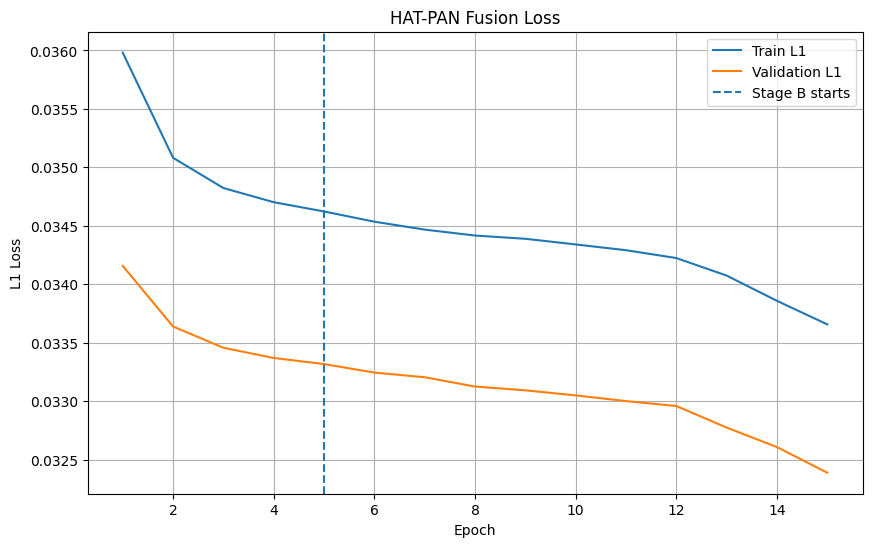

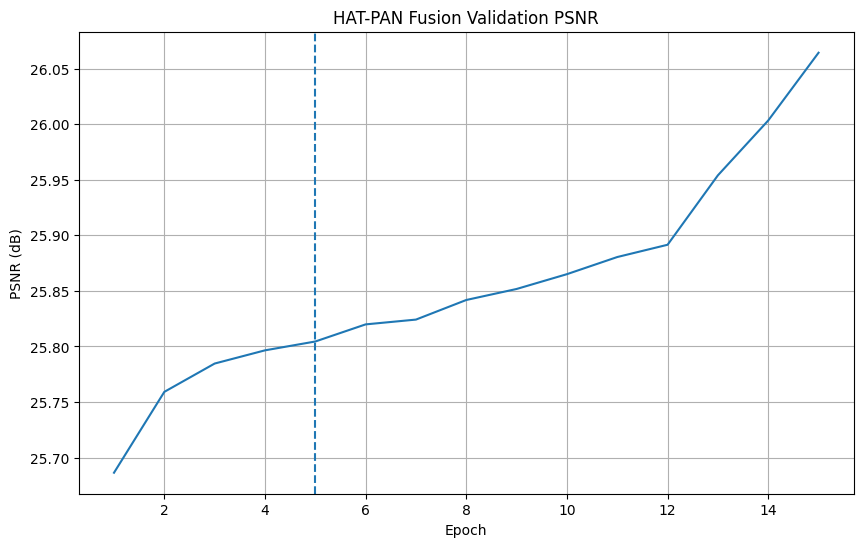

In [17]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history) + 1))

train_losses = [item["train_loss"] for item in history]
val_losses = [item["val_loss"] for item in history]
val_psnr = [item["val_psnr_db"] for item in history]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_losses, label="Train L1")
plt.plot(epochs, val_losses, label="Validation L1")
plt.axvline(STAGE_A_EPOCHS, linestyle="--", label="Stage B starts")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("HAT-PAN Fusion Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(epochs, val_psnr)
plt.axvline(STAGE_A_EPOCHS, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("HAT-PAN Fusion Validation PSNR")
plt.grid()
plt.show()


## 17) Test evaluation and comparison with Bicubic, CNN, and ImageNet-only HAT

In [18]:
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False,
)
model.load_state_dict(best_checkpoint["model_state_dict"])

transfer_test_metrics = evaluate_model(model, test_loader)
comparison = {"wv3_transfer_hat_test": transfer_test_metrics}

if BASELINE_METRICS_PATH.exists():
    with open(BASELINE_METRICS_PATH, "r", encoding="utf-8") as file:
        baseline_metrics = json.load(file)
    comparison["bicubic_test"] = baseline_metrics["bicubic_test"]
    comparison["fusion_cnn_test"] = baseline_metrics["fusion_model_test"]

if OLD_HAT_METRICS_PATH.exists():
    with open(OLD_HAT_METRICS_PATH, "r", encoding="utf-8") as file:
        old_hat_metrics = json.load(file)
    comparison["imageNet_only_hat_test"] = old_hat_metrics[
        "hat_pan_fusion_test"
    ]

if "fusion_cnn_test" in comparison:
    comparison["transfer_vs_cnn_psnr_db"] = (
        transfer_test_metrics["psnr_db"]
        - comparison["fusion_cnn_test"]["psnr_db"]
    )
    comparison["transfer_vs_cnn_sam_degrees"] = (
        comparison["fusion_cnn_test"]["sam_degrees"]
        - transfer_test_metrics["sam_degrees"]
    )

if "imageNet_only_hat_test" in comparison:
    comparison["transfer_vs_old_hat_psnr_db"] = (
        transfer_test_metrics["psnr_db"]
        - comparison["imageNet_only_hat_test"]["psnr_db"]
    )
    comparison["transfer_vs_old_hat_sam_degrees"] = (
        comparison["imageNet_only_hat_test"]["sam_degrees"]
        - transfer_test_metrics["sam_degrees"]
    )

with open(TEST_METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(comparison, file, indent=2, ensure_ascii=False)

print(json.dumps(comparison, indent=2, ensure_ascii=False))
print("Saved:", TEST_METRICS_PATH)


Evaluation:   0%|          | 0/22 [00:00<?, ?it/s]

{
  "wv3_transfer_hat_test": {
    "loss": 0.03420826259323142,
    "psnr_db": 25.35746296969327,
    "sam_degrees": 1.910725479776209
  },
  "bicubic_test": {
    "psnr_db": 18.710798263549805,
    "sam_degrees": 2.6229743162790933
  },
  "fusion_cnn_test": {
    "loss": 0.03530742634426464,
    "psnr_db": 25.076182278719816,
    "sam_degrees": 1.9011461518027566
  },
  "imageNet_only_hat_test": {
    "loss": 0.03657697462900118,
    "psnr_db": 24.88978724046187,
    "sam_degrees": 1.9363497495651245
  },
  "transfer_vs_cnn_psnr_db": 0.2812806909734533,
  "transfer_vs_cnn_sam_degrees": -0.0095793279734524,
  "transfer_vs_old_hat_psnr_db": 0.46767572923139866,
  "transfer_vs_old_hat_sam_degrees": 0.02562426978891552
}
Saved: /content/drive/MyDrive/Super_Resolution_28-07-2026/WV3_Transfer_HAT_Results/transfer_test_metrics.json


## 18) Visual Comparison on Test

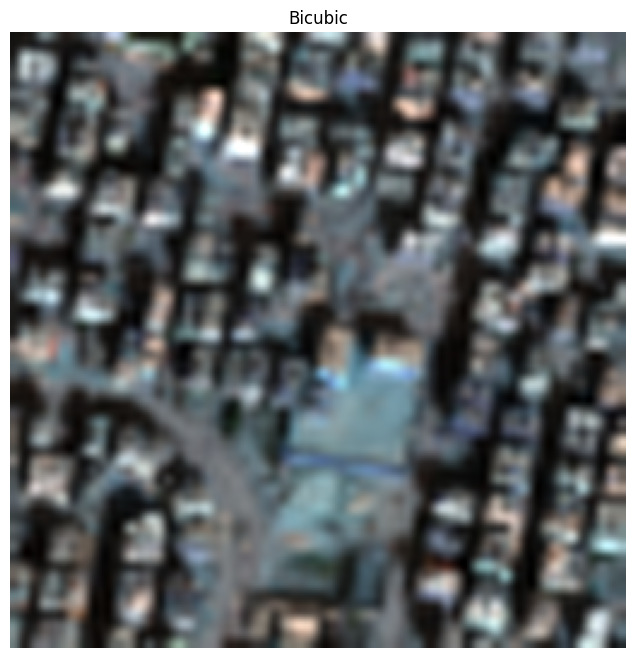

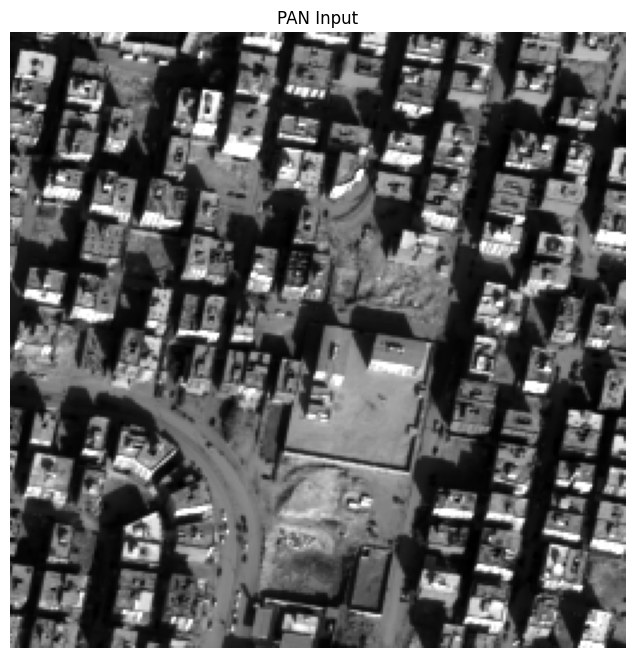

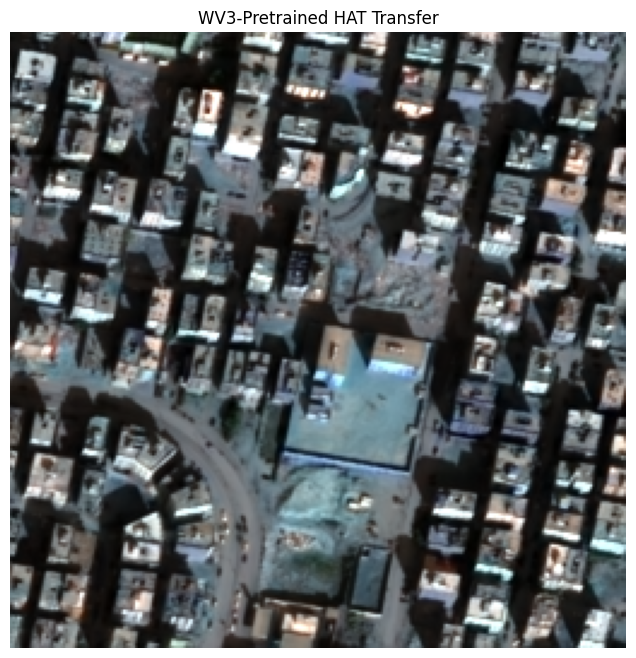

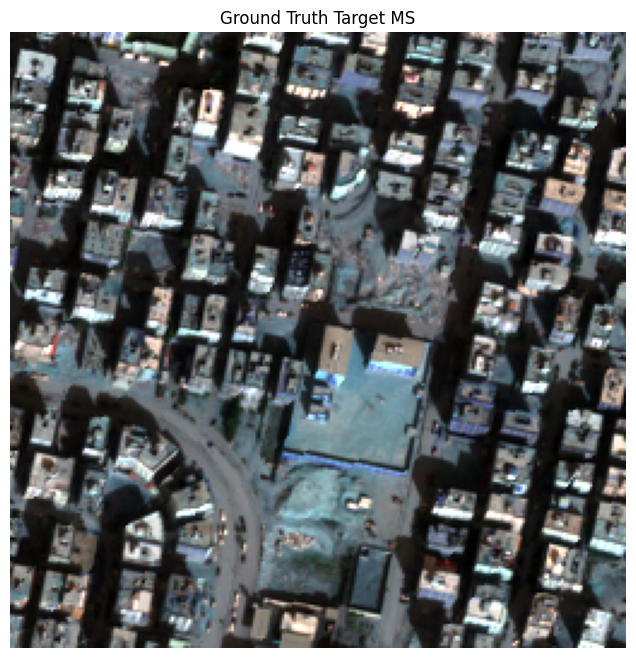

Test file: test_y0000_x1408.npz


In [19]:
test_batch = next(iter(test_loader))

lr_ms = test_batch["lr_ms"].to(device)
pan = test_batch["pan"].to(device)
target = test_batch["target_ms"].to(device)

model.eval()
with torch.inference_mode():
    hat_prediction = model(
        lr_ms.float(),
        pan.float(),
    )

assert torch.isfinite(hat_prediction).all()

bicubic = F.interpolate(
    lr_ms,
    size=target.shape[-2:],
    mode="bicubic",
    align_corners=False,
).clamp(0, 1)


def rgb321_tensor(tensor):
    return torch.stack(
        [tensor[2], tensor[1], tensor[0]],
        dim=-1,
    ).float().clamp(0, 1).cpu().numpy()


plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(bicubic[0]))
plt.title("Bicubic")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(pan[0, 0].cpu().numpy(), cmap="gray")
plt.title("PAN Input")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(hat_prediction[0]))
plt.title("WV3-Pretrained HAT Transfer")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(rgb321_tensor(target[0]))
plt.title("Ground Truth Target MS")
plt.axis("off")
plt.show()

print("Test file:", test_batch["file"][0])


# المطلوب بعد التشغيل

أرسل:

1. `Exact transferred tensors`.
2. نتائج Stage A وStage B.
3. JSON المقارنة النهائية.
4. صورة `WV3-Pretrained HAT Transfer` وصورة Ground Truth.

المقارنة النهائية ستكون بين:

```text
Bicubic
Fusion CNN
HAT initialized from ImageNet only
HAT after WV3 domain pretraining
```
